# Error analysis of cell detection and cell segmentation
To consider:
- Have we infact chosen the correct cutoff frequencies?
- Which data should be included here? All data have not been segmented using same procedure
- We say that we require all area to deviate with less than 50 %. Should this condition be applied before the assesment? At the moment, it isn't.

To DO:
- add Fourier analysis
- update to add patched data
- remove large segmentation errors

In [ ]:
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("scripts/utils/")
from Microscopes       import Holomonitor, Tomocube
from SegmentedCells    import SegmentedCells
from Correlations      import Autocorrelations
from signal_filtering  import butter_lowpass_filter, replace_nan, apply_lowpass
from matrix_operations import detrend_entire_matrix

In [2]:
# Paths
data_path = "../../../../hdd_data/silja/Monolayers"

## Load example data

In [3]:
# Load data
dataset  = "MDCK_20240319_A1-13"
config   = json.load(open(f"configs/{dataset}.json"))

cells = SegmentedCells(f"{data_path}/cell_features/{dataset}_cells.p")

# Set frame rate
if config["microscope"] == "holomonitor":
    microscope = Holomonitor()
elif config["microscope"] == "tomocube":
    microscope = Tomocube()


min_hours = 4 * 1 / microscope.frame_to_h

# Compute duration of each cell track. Used as mask later
duration = np.sum(~cells.A.mask, axis=0)

# Create time array in huors. Used for plotting later
hours    = np.arange(len(cells.A[:,0])) * microscope.frame_to_h

# Filtering doesn't work on nans, so they are replaced by a linear interpolation between edge points.
# The interpolation values are masked, so they don't contribute to any analysis.
data = replace_nan(np.copy(cells.A), cells.A.mask)

State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/MDCK_20240319_A1-13_cells.p.


## Play with lowpass filter

Standard deviation of residuals: 2.97 %


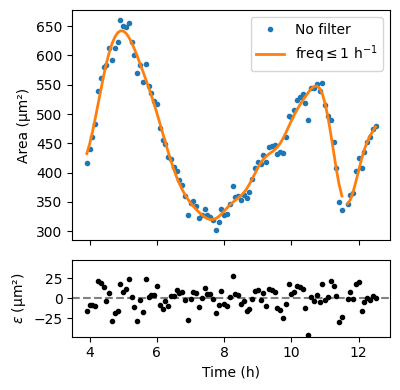

In [4]:
# Filter requirements
order = 6                       # order of the filter
fs = 1 / microscope.frame_to_h  # sample rate, 1/h

# Pick random cell track for illustration
cell = np.random.choice(np.arange(len(duration))[duration > min_hours])
cell = 918

# Cell used for SPIE paper, from holomonitor_20240319_A1-13 old version
#cell = 745  


fig, ax = plt.subplots(2, 1, figsize=(4.1,4), sharex=True, gridspec_kw={'height_ratios':[3,1]})

# Plot data without lowpass
ax[0].plot(hours, cells.A[:,cell], '.', label='No filter')

# Highlight 0 in residual figure
ax[1].axhline(0, ls="dashed", c="gray")

# Plot data that has been filtered
freqs = np.array([1])
for cutoff in freqs:

    # Filter the data
    filtered_data = butter_lowpass_filter(data[:,cell], cutoff, fs, order)
    filtered_data = np.ma.array(filtered_data, mask=cells.A[:,cell].mask)

    # Compute residuals
    residuals = cells.A[:,cell] - filtered_data

    ax[0].plot(hours, filtered_data, '-', linewidth=2, label=rf"freq$ \leq {cutoff}$ h$^{{-1}}$")
    ax[1].plot(hours, residuals, 'k.')


ax[0].legend()
ax[0].set(ylabel='Area (µm²)')
ax[1].set(ylabel=r'$\epsilon$ (µm²)',
          xlabel='Time (h)',
          ylim=[-np.max(abs(residuals))-2, np.max(abs(residuals))+2])

fig.tight_layout()
#fig.savefig("figs/SPIE/track_lowpass.svg")

print(f"Standard deviation of residuals: {100*np.std(residuals) / np.ma.mean(cells.A[:,cell]):0.2f} %")

## Decide on cutoff period

In [5]:
# Compute correlation on example data

# Load correlation object
autocorr_obj = Autocorrelations(f"data/{dataset}_cell_autocorr.p")

# Compute detrended area
detrended_area = detrend_entire_matrix(cells.A[:,duration >= min_hours])
area_variation = np.ma.array(detrended_area - np.ma.mean(detrended_area, axis=0, keepdims=True), mask=False)

# Compute area autocorrelation
tmax = int(len(cells.A) * 0.5)
autocorr_obj.compute_temporal(area_variation, 'AA', tmax, mean_var="cell", t_avrg=True, overwrite=True)

# Save correlation as new variable
Caa_original = autocorr_obj.temporal_cell['AA']

State loaded from data/MDCK_20240319_A1-13_cell_autocorr.p.


100%|██████████| 151/151 [00:01<00:00, 88.81it/s] 


In [6]:
# Run several cutoff frequencies
frequencies = np.array([0.5, 0.6, 0.8, 1, 1.4, 2])
Caa_filtered       = []
segmentation_error = []
correlation_error  = []

for cutoff in frequencies:

    # Apply lowpass filter
    filtered_areas = apply_lowpass(np.copy(cells.A), cells.A.mask, cutoff)

    # Compute segmentation error, only consider data of duration > min_hours
    residual     = cells.A[:,duration >= min_hours] - filtered_areas[:,duration >= min_hours]
    std_residual = np.ma.std(residual, axis=0) / np.ma.mean(cells.A[:,duration >= min_hours])
    segmentation_error.append(np.ma.mean(std_residual))

    # Compute detrended, filtered area
    detrended_filtered_area = detrend_entire_matrix(filtered_areas[:,duration >= min_hours])
    area_filtered_variation = np.ma.array(detrended_filtered_area - np.ma.mean(detrended_filtered_area, axis=0, keepdims=True), mask=False)

    # Compute volume autocorrelation
    autocorr_obj.compute_temporal(area_filtered_variation, 'AA', tmax, mean_var="cell", t_avrg=True, overwrite=True)
    Caa_filtered.append(autocorr_obj.temporal_cell['AA'])

    # Compute chi2
    correlation_error.append(np.ma.sum((autocorr_obj.temporal_cell['AA'] - Caa_original)**2 / abs(Caa_original)))

  3%|▎         | 5/151 [00:00<00:03, 45.09it/s]

100%|██████████| 151/151 [00:01<00:00, 89.81it/s] 


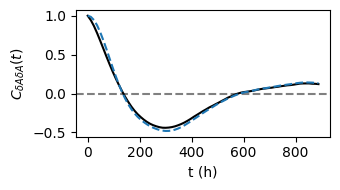

In [7]:
time = autocorr_obj.t_array['AA'] / microscope.frame_to_h

# Plot correlation
fig, ax = plt.subplots(1,1, figsize=(3.5,2))

ax.axhline(0, ls="dashed", c="gray")
ax.plot(time, Caa_original,     '-', c='k')
ax.plot(time, Caa_filtered[2],  '--', c='tab:blue')
ax.set(xlabel=r"t (h)", 
       ylabel=r"$C_{\delta A\delta A}(t)$")

fig.tight_layout()
#fig.savefig("figs/SPIE/correlation.svg")

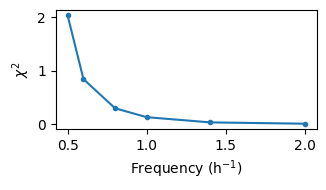

In [8]:
# Plot chi2
fig, ax = plt.subplots(1,1, figsize=(3.5,2))

ax.plot(frequencies, correlation_error,  '.-')
ax.set(xlabel=r"Frequency (h$^{-1}$)", 
       ylabel=r"$\chi^2$")

fig.tight_layout()
#fig.savefig("figs/SPIE/correlation_error.svg")

In [9]:
# Decide on cutoff frequency
cutoff = 1

## Compute standard deviation from all datasets based on cutoff frequency

In [30]:
# Load all data
std_residuals = []

# Load dataset
for tmp_dataset in os.listdir(f"{data_path}/cell_features/"):
    #tmp_dataset = tmp_dataset[0]
    print(tmp_dataset)

   
    # Load if dataset it available
    try:
        tmp_cells = SegmentedCells(f"{data_path}/cell_features/{tmp_dataset}")

        # replace nans so filter can be applied
        tmp_data = replace_nan(np.copy(tmp_cells.A), tmp_cells.A.mask)

    except:
        continue

    # Set frame rate
    if config["microscope"] == "holomonitor":
        microscope = Holomonitor()
    elif config["microscope"] == "tomocube":
        microscope = Tomocube()
 
    fs = 1 / microscope.frame_to_h

    # Compute cutoff track duration in units of frames
    tmp_min_hours = 4 * fs

    # Compute duration of each cell track. Used as mask later
    tmp_duration = np.sum(~tmp_cells.A.mask, axis=0)

    tmp_residuals_std = []
    tmp_residuals_arr = []

    # loop through all cells
    for cell in np.arange(len(tmp_duration))[tmp_duration >= tmp_min_hours]:
        
        # Filter the data compute residual
        filtered_data = np.ma.array(butter_lowpass_filter(tmp_data[:,cell], cutoff, fs, order), mask=tmp_cells.A[:,cell].mask)
        residuals     = tmp_cells.A[:,cell] - filtered_data

        tmp_residuals_std.append(np.ma.std(residuals) / np.ma.mean(tmp_cells.A[:,cell]))
        # tmp_residuals_arr.append(residuals / tmp_cells.A[:,cell])

    std_residuals.append([np.ma.mean(tmp_residuals_std), np.ma.std(tmp_residuals_std) / len(tmp_residuals_std)])

std_residuals = np.array(std_residuals)

MDCK_20240301_B1-4_cells.p
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/MDCK_20240301_B1-4_cells.p.
MDCK_20240319_B1-11_cells.p
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/MDCK_20240319_B1-11_cells.p.
MDCK_20240319_A1-13_cells.p
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/MDCK_20240319_A1-13_cells.p.


In [31]:
print(f"Uncertainty on cell segmentation = {np.mean(std_residuals[:,0])*100:0.2f} +/- {np.std(std_residuals[:,0])*100 / len(std_residuals):0.2f}")

Uncertainty on cell segmentation = 3.87 +/- 0.00


## Computing segmentation error on example dataset

1) Relative std of all residuals: 3.87 %
2) Std of all relative errors:    4.20 %
3) Mean of cell std residuals:    3.72 %


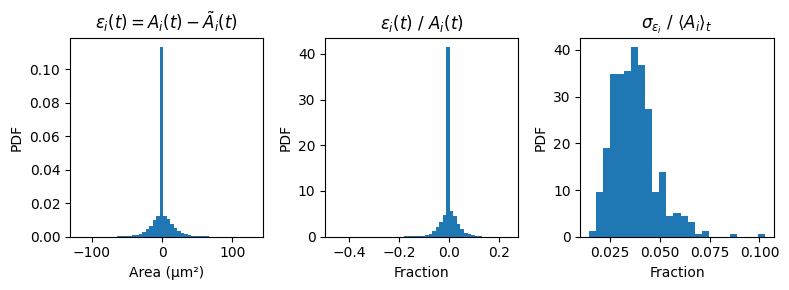

In [32]:
# Apply lowpass filtering to data
filtered_areas = apply_lowpass(np.copy(cells.A), cells.A.mask, cutoff)

# Compute relative residual
residual          = cells.A - filtered_areas
relative_residual = residual / cells.A
std_residual      = np.ma.std(residual, axis=0) / np.ma.mean(cells.A)

# Set lower limit on track length
residual          = residual[:,duration >= min_hours]
relative_residual = relative_residual[:,duration >= min_hours]
std_residual      = std_residual[duration >= min_hours]


# Plot
fig, ax = plt.subplots(1,3, figsize=(8,3))

ax[0].hist(residual.ravel(),  bins=50, density=True);
ax[1].hist(relative_residual.ravel(),  bins=50, density=True);
ax[2].hist(std_residual, bins=25, density=True);

ax[0].set(title=r"$\epsilon_i(t) = A_i(t) - \tilde{A}_i(t)$",       xlabel="Area (µm²)", ylabel="PDF");
ax[1].set(title=r"$\epsilon_i(t) ~/~ A_i(t)$",                      xlabel="Fraction",   ylabel="PDF");
ax[2].set(title=r"$\sigma_{\epsilon_i} ~/~ \langle A_i \rangle_t$", xlabel="Fraction",   ylabel="PDF");

fig.tight_layout()

print(f"1) Relative std of all residuals: {100*np.ma.std(residual) / np.ma.mean(cells.A):0.2f} %")
print(f"2) Std of all relative errors:    {100*np.ma.std(relative_residual):0.2f} %")
print(f"3) Mean of cell std residuals:    {100*np.ma.mean(std_residual):0.2f} %")

## Cell detection error

0.6157797885596892


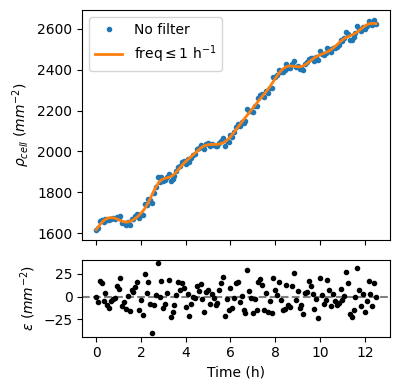

In [33]:
# Filter requirements
order  = 6
fs     = 1 / microscope.frame_to_h   # sample rate, 1/h

# Create figure for SPIE
fig, ax = plt.subplots(2, 1, figsize=(4.1,4), sharex=True, gridspec_kw={'height_ratios':[3,1]})

# Plot data without filter
ax[0].plot(hours, cells.density, '.', label='No filter')

# Highlight 0 in residual figure
ax[1].axhline(0, ls="dashed", c="gray")

# Plot data that has been filtered
frequencies = np.array([1])
for cutoff in frequencies:

    # Filter the data, and plot both the original and filtered signals.
    filtered_data = butter_lowpass_filter(cells.density, cutoff, fs, order)
    filtered_data = np.ma.array(filtered_data)
    residuals     = cells.density - filtered_data

    ax[0].plot(hours, filtered_data, '-', linewidth=2, label=rf"freq$ \leq ${cutoff} h$^{{-1}}$")

ax[1].plot(hours, residuals, 'k.')
print(100*np.std(residuals) / np.mean(cells.density))

ax[0].set(ylabel=r"$\rho_{cell}~(mm^{-2})$")
ax[0].legend()


ax[1].set(ylabel=r'$\epsilon~(mm^{-2})$',
        xlabel='Time (h)')#,
        #ylim=[-np.max(abs(residuals)), np.max(abs(residuals))])

fig.tight_layout()
#fig.savefig("figs/SPIE/detetion_error.svg")


## Get standard deviation from all datasets



In [38]:
cutoff = 1
std_residuals_by_density = []
std_residuals_by_mean_density = []

# Load data
for tmp_dataset in os.listdir(f"{data_path}/cell_features/"):

    # Load if tmp_dataset it available
    try:
        cellprop = SegmentedCells(f"{data_path}/cell_features/{tmp_dataset}")
    
    except:
        continue

    # Set frame rate
    if config["microscope"] == "holomonitor":
        microscope = Holomonitor()
    elif config["microscope"] == "tomocube":
        microscope = Tomocube()
 
    fs = 1 / microscope.frame_to_h


    # Filter the data and get residuals
    filtered_data = np.ma.array(butter_lowpass_filter(cellprop.density, cutoff, fs, order))
    residuals     = cellprop.density - filtered_data

    std_residuals_by_density.append(np.ma.std(residuals / cellprop.density))
    std_residuals_by_mean_density.append(np.ma.std(residuals) / np.mean(cellprop.density))
    

State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/MDCK_20240301_B1-4_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/MDCK_20240319_B1-11_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/MDCK_20240319_A1-13_cells.p.


In [39]:
print(f"Uncertainty on cell detection = {np.mean(std_residuals_by_mean_density)*100:0.2f} +/- {np.std(std_residuals_by_mean_density)*100 / len(std_residuals_by_mean_density):0.2f}")

Uncertainty on cell detection = 0.59 +/- 0.01
